In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

Matplotlib is building the font cache; this may take a moment.


In [ ]:
df_full=pd.read_csv("April2025_full_model_merged.csv")
df_free=pd.read_csv("master_3models.csv")

Index(['ID', 'Investor_NLL', 'Investor_ToM', 'Investor_Planning_Steps',
       'Investor_Guilt_Parameter', 'Investor_Inverse_Temperature',
       'Investor_Risk_Aversion', 'Investor_Irritability',
       'Investor_Irritation_Belief', 'Trustee_NLL', 'Trustee_ToM',
       'Trustee_Planning_Steps', 'Trustee_Guilt_Parameter',
       'Trustee_Inverse_Temperature', 'Trustee_Risk_Aversion',
       'Trustee_Irritability', 'Trustee_Irritation_Belief', 'subjectid',
       'group', 'Age', 'Gender', 'Edu_years', 'time_line_follow_back',
       'sds_total', 'disease_duration', 'full_scale_iq', 'ace_total',
       'cape_pi_total', 'cape_be_total', 'cape_pa_total', 'cape_total',
       'staxi_anger_index', 'qol_total', 'cesd_total', 'psychotic_symptoms',
       'mini_k7_CurrentPsychDrugInduc', 'date', 'uds_thc', 'uds_coc',
       'uds_meth', 'uds_amph', 'uds_benz', 'uds_mdma', 'uds_opi', 'scid_1',
       'scid_2', 'scid_3'],
      dtype='str')
Index(['subjectid', 'M2_fairness', 'M2_baseline', 'M2_wei

In [ ]:
# columns to bring in from df_free
cols_to_add = [
    'subjectid',
    'success',
    'trustworthiness',
    'bot_trust',
    'bot_success'
]

# subset df_free to only needed columns
df_free_sub = df_free[cols_to_add].copy()

# merge into df_full (left join = keep df_full intact)
df_full = df_full.merge(
    df_free_sub,
    how='left',
    left_on='subjectid',
    right_on='subjectid'
)

# optional: drop duplicate ID column from df_free
df_full = df_full.drop(columns=['ID'])



In [5]:
# check how many rows got data
print(df_full[['success', 'trustworthiness', 'bot_trust', 'bot_success']].notna().sum())

# check for duplicate subject IDs in df_free (can cause row inflation)
print("Duplicates in df_free IDs:",
      df_free['subjectid'].duplicated().sum())



success            93
trustworthiness    93
bot_trust          93
bot_success        93
dtype: int64
Duplicates in df_free IDs: 0


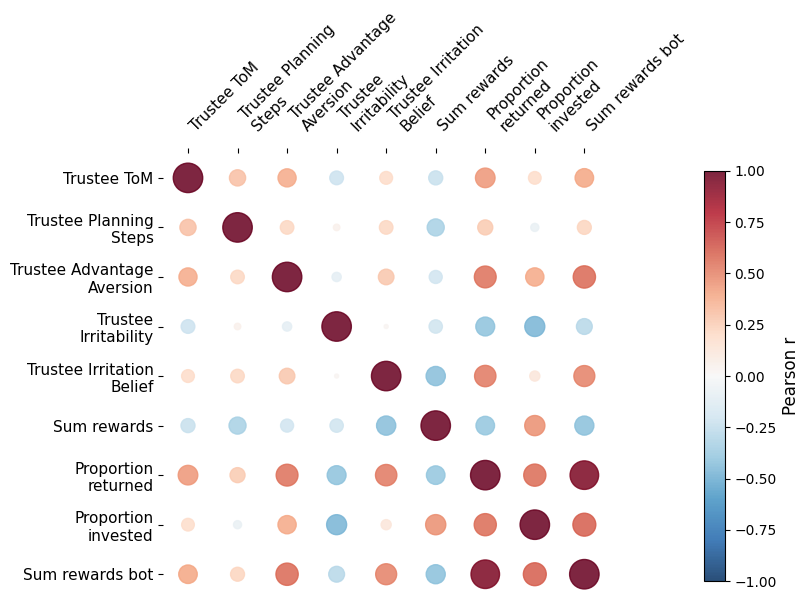

In [ ]:


# --------------------------------------------------
exclude_cols = [
    'ID',
    'Investor_NLL',
    'Investor_ToM',
    'Investor_Planning_Steps',
    'Investor_Guilt_Parameter',
    'Investor_Inverse_Temperature',
    'Investor_Risk_Aversion',
    'Investor_Irritability',
    'Investor_Irritation_Belief',
    'Trustee_NLL',
    'Trustee_Risk_Aversion',
    'Trustee_Inverse_Temperature',
    'subjectid',
    'group',
    'date', 'uds_thc', 'uds_coc',
    'uds_meth', 'uds_amph', 'uds_benz', 'uds_mdma', 'uds_opi',
    'Age', 'Edu_years', 'time_line_follow_back', 'sds_total', 'disease_duration', 'full_scale_iq',
    'ace_total', 'cape_pi_total', 'cape_be_total', 'cape_pa_total', 'cape_total',
    'staxi_anger_index', 'qol_total', 'cesd_total', 'mini_k7_CurrentPsychDrugInduc',
    'scid_1', 'scid_2', 'scid_3'
]
# --------------------------------------------------

df = df_full.drop(columns=exclude_cols, errors='ignore')
df_num = df.select_dtypes(include='number')

df_num = df_num.loc[
    :, (df_num.notna().sum() >= 2) & (df_num.nunique(dropna=True) > 1)
]

# reorder: put free-task columns right after Trustee_Irritation_Belief
insert_after = 'Trustee_Irritation_Belief'
cols_to_insert = ['success', 'trustworthiness', 'bot_trust', 'bot_success']

cols = list(df_num.columns)
missing = [c for c in cols_to_insert + [insert_after] if c not in cols]
if missing:
    raise ValueError(f"These columns are missing from df_num: {missing}")

cols = [c for c in cols if c not in cols_to_insert]
idx = cols.index(insert_after) + 1
df_num = df_num[cols[:idx] + cols_to_insert + cols[idx:]]

corr = df_num.corr()

corr_long = (
    corr.reset_index()
        .melt(id_vars='index')
        .rename(columns={'index': 'var_x', 'variable': 'var_y', 'value': 'r'})
)

display_names = {
    'Trustee_ToM': 'Trustee ToM',
    'Trustee_Guilt_Parameter': 'Trustee Advantage Aversion',
    'Trustee_Irritability': 'Trustee Irritability',
    'Trustee_Planning_Steps': 'Trustee Planning Steps',
    'Trustee_Irritation_Belief': 'Trustee Irritation Belief',
    'success': 'Sum rewards',
    'trustworthiness': 'Proportion returned',
    'bot_trust': 'Proportion invested',
    'bot_success': 'Sum rewards bot',
}

# use display names (fallback to original)
labels = [display_names.get(c, c) for c in corr.columns]
n = len(labels)

# OPTIONAL: wrap long labels to reduce footprint
wrap_width = 18
labels_wrapped = [textwrap.fill(l, width=wrap_width) for l in labels]

# ---- layout parameters ----
label_fs = 11
title_fs = 16

# make sure figure doesn’t collapse for small n
fig_w = max(8, 0.7 * n)
fig_h = max(8, 0.7 * n)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

sc = ax.scatter(
    corr_long['var_x'],
    corr_long['var_y'],
    s=np.abs(corr_long['r']) * 450,   # slightly smaller bubbles
    c=corr_long['r'],
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    alpha=0.85
)

ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.xaxis.tick_top()
ax.tick_params(axis='x', pad=10)  # extra space from the axis
ax.set_xticklabels(labels_wrapped, rotation=45, ha='left', fontsize=label_fs)
ax.set_yticklabels(labels_wrapped, fontsize=label_fs)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.invert_yaxis()
ax.set_aspect('equal')

for spine in ax.spines.values():
    spine.set_visible(False)

#ax.set_title('Correlation matrix (numeric variables only)', fontsize=title_fs, pad=30)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.show()


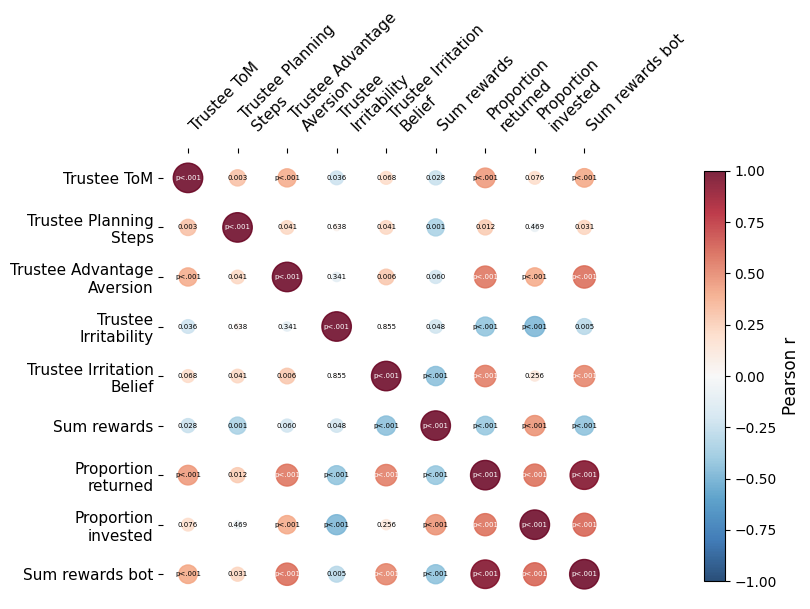

In [10]:
from scipy.stats import pearsonr

# p-values
cols = list(df_num.columns)
pvals = pd.DataFrame(np.nan, index=cols, columns=cols)

for i, x in enumerate(cols):
    for j, y in enumerate(cols):
        tmp = df_num.iloc[:, [i, j]].dropna()
        xvals = tmp.iloc[:, 0]
        yvals = tmp.iloc[:, 1]

        if len(tmp) >= 2 and xvals.nunique() > 1 and yvals.nunique() > 1:
            _, p = pearsonr(xvals, yvals)
            pvals.iloc[i, j] = p

# rebuild long table
corr_long_p = (
    corr.reset_index()
        .melt(id_vars='index')
        .rename(columns={'index': 'var_x', 'variable': 'var_y', 'value': 'r'})
)

# plot again
fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

sc = ax.scatter(
    corr_long_p['var_x'],
    corr_long_p['var_y'],
    s=np.abs(corr_long_p['r']) * 450,
    c=corr_long_p['r'],
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    alpha=0.85
)

for i, x in enumerate(cols):
    for j, y in enumerate(cols):
        p = pvals.iloc[i, j]

        if pd.isna(p):
            label = ""
        elif p < 0.001:
            label = "p<.001"
        else:
            label = f"{p:.3f}"

        r = corr.iloc[i, j]
        text_color = "white" if abs(r) > 0.5 else "black"

        ax.text(i, j, label, ha='center', va='center', fontsize=5, color=text_color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.xaxis.tick_top()
ax.tick_params(axis='x', pad=10)
ax.set_xticklabels(labels_wrapped, rotation=45, ha='left', fontsize=label_fs)
ax.set_yticklabels(labels_wrapped, fontsize=label_fs)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.invert_yaxis()
ax.set_aspect('equal')

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.show()

In [15]:
#df_full['group'].unique()
df_full = df_full[df_full['group'] != 'HC']
df_full = df_full.dropna(subset=['Age', 'Gender', 'full_scale_iq'])

Number of participants (rows) used for correlations: 45
Final column order:
00: Trustee_ToM
01: Trustee_Planning_Steps
02: Trustee_Guilt_Parameter
03: Trustee_Irritability
04: Trustee_Irritation_Belief
05: success
06: trustworthiness
07: bot_trust
08: bot_success
09: Age
10: Edu_years
11: time_line_follow_back
12: full_scale_iq
13: ace_total
14: cape_total
15: staxi_anger_index
16: qol_total
17: cesd_total
18: scid_1
19: scid_2
20: scid_3


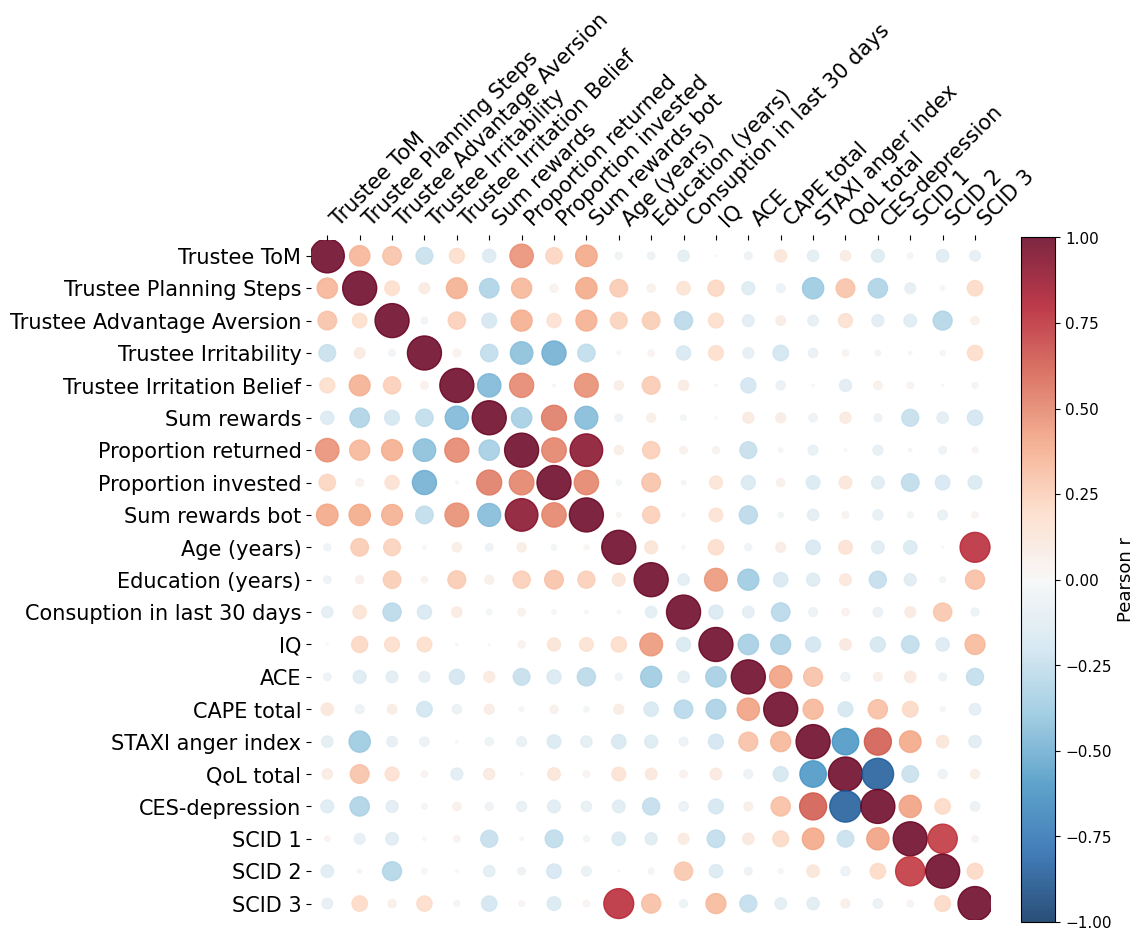

In [ ]:

exclude_cols = [
    'ID',
    'Investor_NLL',
    'Investor_ToM',
    'Investor_Planning_Steps',
    'Investor_Guilt_Parameter',
    'Investor_Inverse_Temperature',
    'Investor_Risk_Aversion',
    'Investor_Irritability',
    'Investor_Irritation_Belief',
    'Trustee_NLL',
    'Trustee_Risk_Aversion',
    'Trustee_Inverse_Temperature',  
    'subjectid',
    'group',
    'date', 'uds_thc', 'uds_coc',
    'uds_meth', 'uds_amph', 'uds_benz', 'uds_mdma', 'uds_opi',
    'sds_total', 'disease_duration', 'cape_pi_total', 'cape_be_total', 'cape_pa_total',
    'mini_k7_CurrentPsychDrugInduc'
]

df = df_full.drop(columns=exclude_cols, errors='ignore')
df_num = df.select_dtypes(include='number')

df_num = df_num.loc[
    :, (df_num.notna().sum() >= 2) & (df_num.nunique(dropna=True) > 1)
]

print("Number of participants (rows) used for correlations:", len(df_num))

# --------------------------------------------------
# reorder columns
# --------------------------------------------------
insert_after = 'Trustee_Irritation_Belief'
cols_to_insert = ['success', 'trustworthiness', 'bot_trust', 'bot_success']

cols = list(df_num.columns)

missing = [c for c in cols_to_insert + [insert_after] if c not in cols]
if missing:
    raise ValueError(f"These columns are missing from df_num: {missing}")

cols = [c for c in cols if c not in cols_to_insert]
idx = cols.index(insert_after) + 1
new_cols = cols[:idx] + cols_to_insert + cols[idx:]

df_num = df_num[new_cols]

print("Final column order:")
for i, c in enumerate(df_num.columns):
    print(f"{i:02d}: {c}")

# --------------------------------------------------
# correlations
# --------------------------------------------------
corr = df_num.corr()
cols = list(df_num.columns)
n = len(cols)

corr_long = (
    corr.reset_index()
        .melt(id_vars='index')
        .rename(columns={'index': 'var_x', 'variable': 'var_y', 'value': 'r'})
)

# --------------------------------------------------
# p-values
# --------------------------------------------------
pvals = pd.DataFrame(np.nan, index=cols, columns=cols)

for i, x in enumerate(cols):
    for j, y in enumerate(cols):

        tmp = df_num.iloc[:, [i, j]].dropna()
        xvals = tmp.iloc[:, 0]
        yvals = tmp.iloc[:, 1]

        if len(tmp) >= 2 and xvals.nunique() > 1 and yvals.nunique() > 1:
            _, p = pearsonr(xvals, yvals)
            pvals.iloc[i, j] = p

# --------------------------------------------------
# display names
# --------------------------------------------------
display_names = {
    'Age': 'Age (years)',
    'Edu_years': 'Education (years)',
    'full_scale_iq': 'IQ',
    'disease_duration': 'Disorder duration',
    'scid_1': 'SCID 1',
    'scid_2': 'SCID 2',
    'scid_3': 'SCID 3',
    'uds_thc': 'UDS THC',
    'uds_coc': 'UDS cocaine',
    'uds_amph': 'UDS amphetamines',
    'uds_opi': 'UDS opiates',
    'uds_benz': 'UDS benzodiazepines',
    'uds_meth': 'UDS methamphetamine',
    'uds_mdma': 'UDS MDMA',
    'mini_k7_CurrentPsychDrugInduc': 'Mini K7 Drug-Induced',
    'Trustee_ToM': 'Trustee ToM',
    'Trustee_Guilt_Parameter': 'Trustee Advantage Aversion',
    'Trustee_Irritability': 'Trustee Irritability',
    'Trustee_Planning_Steps': 'Trustee Planning Steps',
    'Trustee_Irritation_Belief': 'Trustee Irritation Belief',
    'success': 'Sum rewards',
    'trustworthiness': 'Proportion returned',
    'bot_trust': 'Proportion invested',
    'bot_success': 'Sum rewards bot',
    'time_line_follow_back': 'Consumption in last 30 days', 
    'sds_total': 'SDS total', 
    'ace_total': 'ACE',
    'cape_pi_total': 'CAPE positive symptoms', 
    'cape_be_total': 'CAPE bizarre experiences', 
    'cape_pa_total': 'CAPE positive affect', 
    'cape_total': 'CAPE total', 
    'staxi_anger_index': 'STAXI anger index', 
    'qol_total': 'QoL total', 
    'cesd_total': 'CES-depression',
    'bdi_total': 'BDI total',
    'bai_total': 'BAI total',
    'bis_total': 'BIS total',
    'bhs_total': 'BHS total',
    'ctq_total': 'CTQ total',
    'perceived_stress_scale': 'PSS',
    'lsas_total': 'LSAS total',
    'auditory_hallucinations': 'Auditory hallucinations',
    'delusions': 'Delusions',
    'paranoia': 'Paranoia',
    'depression': 'Depression symptoms',
    'anxiety': 'Anxiety symptoms'
}

labels = [display_names.get(c, c) for c in cols]

# --------------------------------------------------
# balanced plot sizing
# --------------------------------------------------
fig_size = max(14, 0.8 * n)
label_fs = max(7, min(12, 220 / n))
p_fs = max(4, min(8, 140 / n))
bubble_scale = max(120, 9000 / n)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sc = ax.scatter(
    corr_long['var_x'],
    corr_long['var_y'],
    s=np.abs(corr_long['r']) * bubble_scale,
    c=corr_long['r'],
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    alpha=0.85
)

# p-values inside bubbles
for i, x in enumerate(cols):
    for j, y in enumerate(cols):

        p = pvals.iloc[i, j]

        if pd.isna(p):
            label = ""
        elif p < 0.001:
            label = "<.001"
        else:
            label = f"{p:.2f}"

        r = corr.iloc[i, j]
        text_color = "white" if abs(r) > 0.5 else "black"

        ax.text(
            i,
            j,
            label,
            ha='center',
            va='center',
            fontsize=p_fs,
            color=text_color
        )

# axes formatting
ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.xaxis.tick_top()
ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=label_fs)
ax.set_yticklabels(labels, fontsize=label_fs)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.invert_yaxis()
ax.set_aspect('equal')

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=label_fs)
cbar.ax.tick_params(labelsize=label_fs - 1)

plt.tight_layout()
plt.show()


Number of participants (rows) used for correlations: 45
Final column order:
00: Trustee_ToM
01: Trustee_Planning_Steps
02: Trustee_Guilt_Parameter
03: Trustee_Irritability
04: Trustee_Irritation_Belief
05: success
06: trustworthiness
07: bot_trust
08: bot_success
09: Age
10: Edu_years
11: time_line_follow_back
12: full_scale_iq
13: ace_total
14: cape_total
15: staxi_anger_index
16: qol_total
17: cesd_total
18: scid_1
19: scid_2
20: scid_3


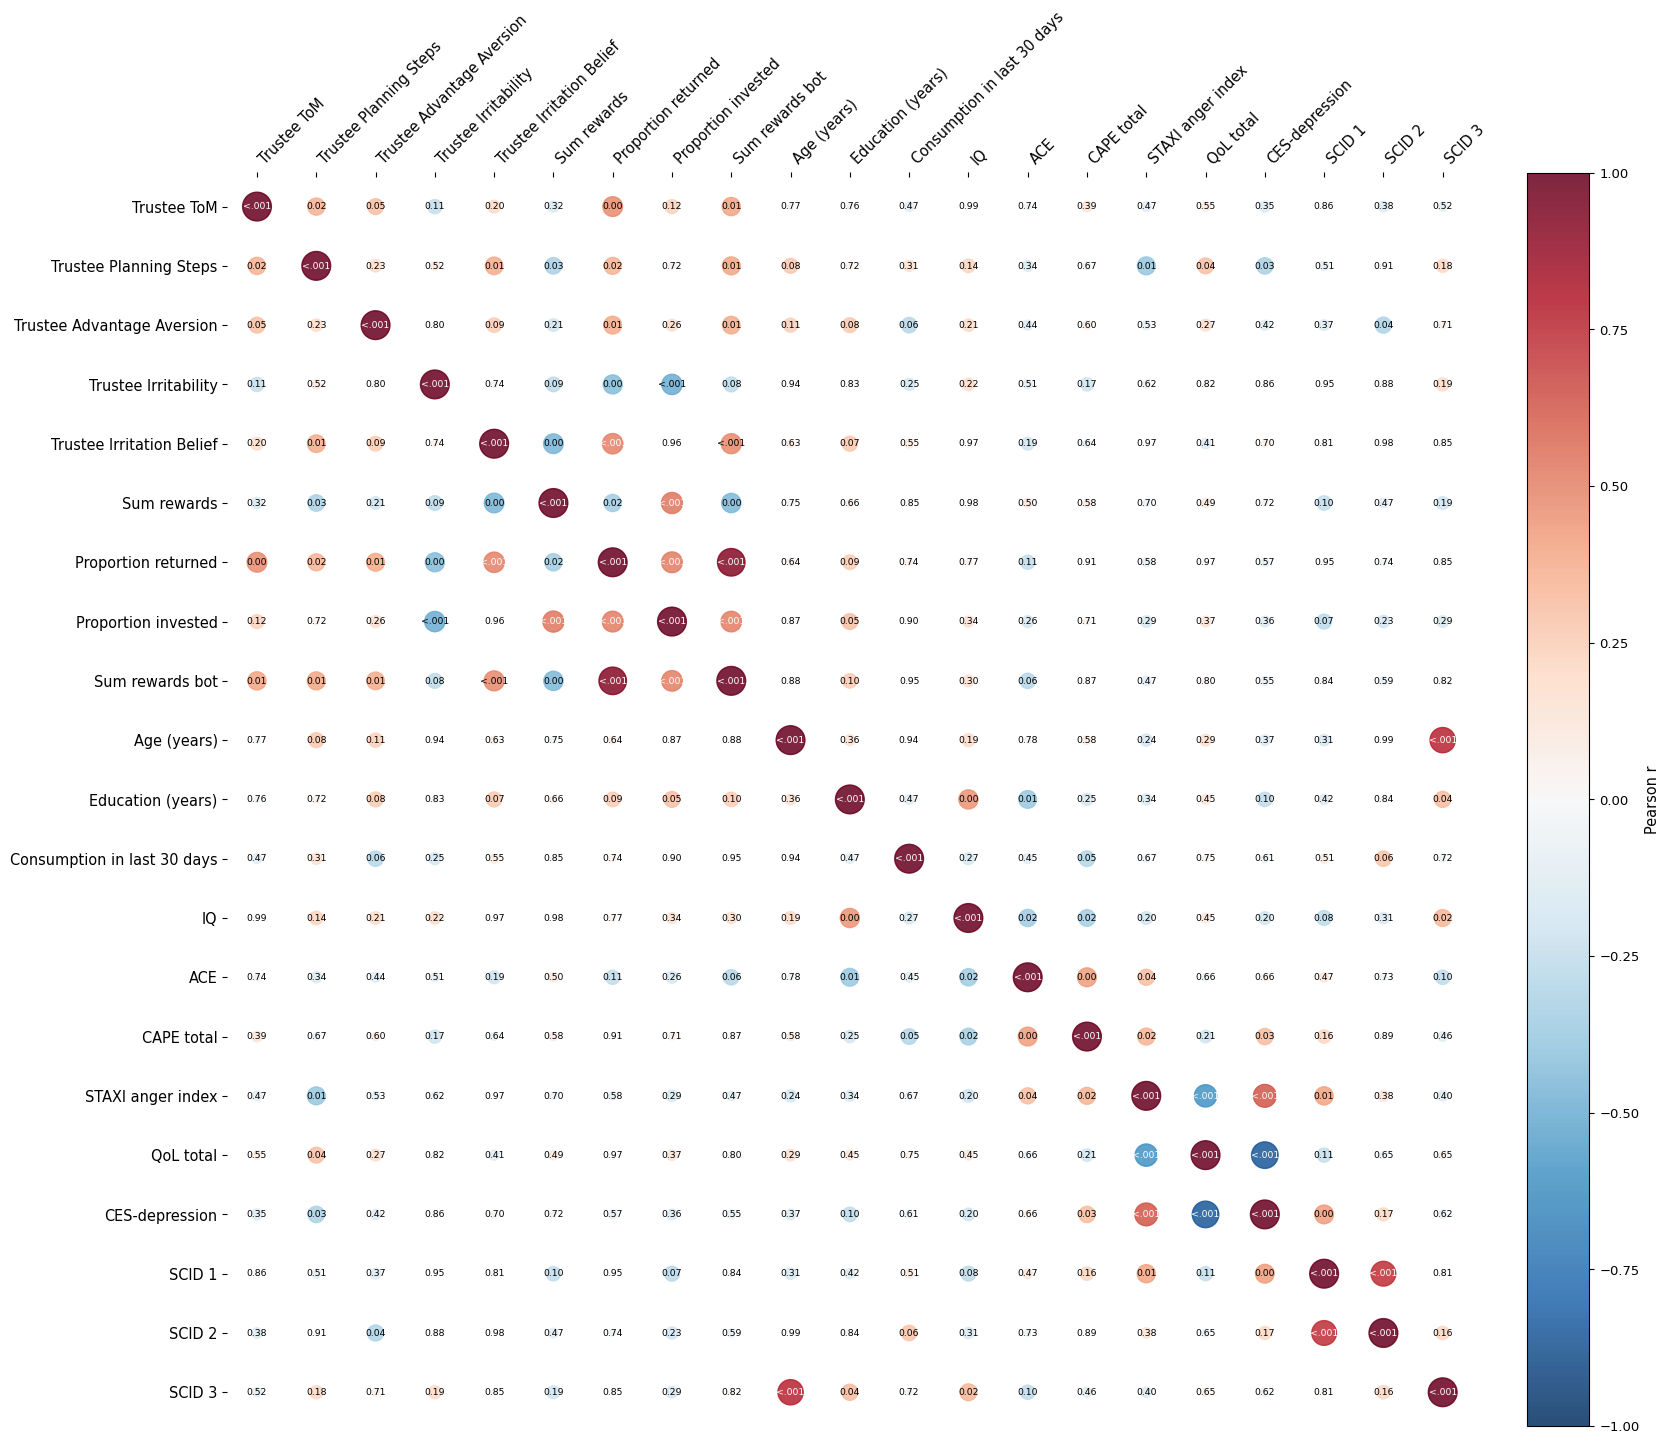

In [16]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# explicitly exclude these columns
# --------------------------------------------------
exclude_cols = [
    'ID',
    'Investor_NLL',
    'Investor_ToM',
    'Investor_Planning_Steps',
    'Investor_Guilt_Parameter',
    'Investor_Inverse_Temperature',
    'Investor_Risk_Aversion',
    'Investor_Irritability',
    'Investor_Irritation_Belief',
    'Trustee_NLL',
    'Trustee_Risk_Aversion',
    'Trustee_Inverse_Temperature',  
    'subjectid',
    'group',
    'date', 'uds_thc', 'uds_coc',
    'uds_meth', 'uds_amph', 'uds_benz', 'uds_mdma', 'uds_opi',
    'sds_total', 'disease_duration', 'cape_pi_total', 'cape_be_total', 'cape_pa_total',
    'mini_k7_CurrentPsychDrugInduc'
]

df = df_full.drop(columns=exclude_cols, errors='ignore')
df_num = df.select_dtypes(include='number')

df_num = df_num.loc[
    :, (df_num.notna().sum() >= 2) & (df_num.nunique(dropna=True) > 1)
]

print("Number of participants (rows) used for correlations:", len(df_num))

# --------------------------------------------------
# reorder columns
# --------------------------------------------------
insert_after = 'Trustee_Irritation_Belief'
cols_to_insert = ['success', 'trustworthiness', 'bot_trust', 'bot_success']

cols = list(df_num.columns)

missing = [c for c in cols_to_insert + [insert_after] if c not in cols]
if missing:
    raise ValueError(f"These columns are missing from df_num: {missing}")

cols = [c for c in cols if c not in cols_to_insert]
idx = cols.index(insert_after) + 1
new_cols = cols[:idx] + cols_to_insert + cols[idx:]

df_num = df_num[new_cols]

print("Final column order:")
for i, c in enumerate(df_num.columns):
    print(f"{i:02d}: {c}")

# --------------------------------------------------
# correlations
# --------------------------------------------------
corr = df_num.corr()
cols = list(df_num.columns)
n = len(cols)

corr_long = (
    corr.reset_index()
        .melt(id_vars='index')
        .rename(columns={'index': 'var_x', 'variable': 'var_y', 'value': 'r'})
)

# --------------------------------------------------
# p-values
# --------------------------------------------------
pvals = pd.DataFrame(np.nan, index=cols, columns=cols)

for i, x in enumerate(cols):
    for j, y in enumerate(cols):

        tmp = df_num.iloc[:, [i, j]].dropna()
        xvals = tmp.iloc[:, 0]
        yvals = tmp.iloc[:, 1]

        if len(tmp) >= 2 and xvals.nunique() > 1 and yvals.nunique() > 1:
            _, p = pearsonr(xvals, yvals)
            pvals.iloc[i, j] = p

# --------------------------------------------------
# display names
# --------------------------------------------------
display_names = {
    'Age': 'Age (years)',
    'Edu_years': 'Education (years)',
    'full_scale_iq': 'IQ',
    'disease_duration': 'Disorder duration',
    'scid_1': 'SCID 1',
    'scid_2': 'SCID 2',
    'scid_3': 'SCID 3',
    'uds_thc': 'UDS THC',
    'uds_coc': 'UDS cocaine',
    'uds_amph': 'UDS amphetamines',
    'uds_opi': 'UDS opiates',
    'uds_benz': 'UDS benzodiazepines',
    'uds_meth': 'UDS methamphetamine',
    'uds_mdma': 'UDS MDMA',
    'mini_k7_CurrentPsychDrugInduc': 'Mini K7 Drug-Induced',
    'Trustee_ToM': 'Trustee ToM',
    'Trustee_Guilt_Parameter': 'Trustee Advantage Aversion',
    'Trustee_Irritability': 'Trustee Irritability',
    'Trustee_Planning_Steps': 'Trustee Planning Steps',
    'Trustee_Irritation_Belief': 'Trustee Irritation Belief',
    'success': 'Sum rewards',
    'trustworthiness': 'Proportion returned',
    'bot_trust': 'Proportion invested',
    'bot_success': 'Sum rewards bot',
    'time_line_follow_back': 'Consumption in last 30 days', 
    'sds_total': 'SDS total', 
    'ace_total': 'ACE',
    'cape_pi_total': 'CAPE positive symptoms', 
    'cape_be_total': 'CAPE bizarre experiences', 
    'cape_pa_total': 'CAPE positive affect', 
    'cape_total': 'CAPE total', 
    'staxi_anger_index': 'STAXI anger index', 
    'qol_total': 'QoL total', 
    'cesd_total': 'CES-depression',
    'bdi_total': 'BDI total',
    'bai_total': 'BAI total',
    'bis_total': 'BIS total',
    'bhs_total': 'BHS total',
    'ctq_total': 'CTQ total',
    'perceived_stress_scale': 'PSS',
    'lsas_total': 'LSAS total',
    'auditory_hallucinations': 'Auditory hallucinations',
    'delusions': 'Delusions',
    'paranoia': 'Paranoia',
    'depression': 'Depression symptoms',
    'anxiety': 'Anxiety symptoms'
}

labels = [display_names.get(c, c) for c in cols]

# --------------------------------------------------
# balanced plot sizing
# --------------------------------------------------
fig_size = max(14, 0.8 * n)
label_fs = max(7, min(12, 220 / n))
p_fs = max(4, min(8, 140 / n))
bubble_scale = max(120, 9000 / n)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sc = ax.scatter(
    corr_long['var_x'],
    corr_long['var_y'],
    s=np.abs(corr_long['r']) * bubble_scale,
    c=corr_long['r'],
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    alpha=0.85
)

# p-values inside bubbles
for i, x in enumerate(cols):
    for j, y in enumerate(cols):

        p = pvals.iloc[i, j]

        if pd.isna(p):
            label = ""
        elif p < 0.001:
            label = "<.001"
        else:
            label = f"{p:.2f}"

        r = corr.iloc[i, j]
        text_color = "white" if abs(r) > 0.5 else "black"

        ax.text(
            i,
            j,
            label,
            ha='center',
            va='center',
            fontsize=p_fs,
            color=text_color
        )

# axes formatting
ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.xaxis.tick_top()
ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=label_fs)
ax.set_yticklabels(labels, fontsize=label_fs)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.invert_yaxis()
ax.set_aspect('equal')

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=label_fs)
cbar.ax.tick_params(labelsize=label_fs - 1)

plt.tight_layout()
plt.show()
